In [83]:
import pandas as pd
df = pd.read_csv("./datasets/flight_weather_sample_100k.csv")
# Dropping Attributes, USEFUL for debugging but cause unnecessary clutter
df = df.drop(columns=[c for c in df.columns if c.endswith("_ATTRIBUTES")])

def fill_origin_dest(df, col_name, value):
    """Fill both ORIGIN_{col} and DEST_{col} columns with a specified value."""
    origin_col = f"ORIGIN_{col_name}"
    dest_col = f"DEST_{col_name}"
    cols = [c for c in (origin_col, dest_col) if c in df.columns]
    df[cols] = df[cols].fillna(value)
    return df

def drop_col(df, col_name):
    df.drop(columns=["ORIGIN_"+col_name, "DEST_"+col_name], inplace=True)

def drop_prefix(df, col_name):
    """Drop all columns with a specified prefix"""
    origin_col = f"ORIGIN_{col_name}"
    dest_col = f"DEST_{col_name}"
    cols = [c for c in df.columns if c.startswith(origin_col)] + [c for c in df.columns if c.startswith(dest_col)]
    df = df.drop(columns=cols)
    return df

# No snowfall recorded means 0.0 snowfall.
fill_origin_dest(df, "SNOW", 0.0)
fill_origin_dest(df, "SNWD", 0.0) #same logic for depth
# df["DEP_DELAY"].where(df["CANCELLED"] == 1).fillna(999.9) # NAN values represent canceled flights, give major delay for correlation finding
df.dropna(axis=1, how="all", inplace=True)
drop_col(df, "TAVG") #Same info as TMIN and TMAX but more null vals
drop_col(df, "TSUN") # Only 4 non nan
drop_col(df, "PSUN") # Same Reason
drop_col(df, "DAPR") # 6 non-nan
drop_col(df, "MDPR") # 6 non-nan
drop_col(df, "PGTM")  # Not doing analysis at this timescale
drop_col(df, "WDFG") # High amount of NULL high overlap with other wind stats
drop_col(df, "WSFG") # High amount of NULL high overlap with other wind stats
drop_col(df, "WESD") # OVERLAP with snow fall
drop_col(df, "WDMV") # Too many Null
drop_col(df, "EVAP") # Too many Null - Non-standard testing
drop_col(df, "MNPN")
drop_col(df, "MXPN")
drop_col(df, "WESF") # OVERLAP with snow fall
df = drop_prefix(df, "SX") # Refers to Soil Temps, not relevant to the findings
drop_col(df, "SN32")
drop_col(df, "SN52")
drop_col(df, "TOBS") # TO MANY NULL VALUES
drop_col(df, "ASTP") # Just care about ACSH
drop_col(df, "ASLP") #
drop_col(df, "AWBT")

def fill_catetorical_dtypes(df, col_prefix, value=0):
    origin_col = f"ORIGIN_{col_prefix}"
    dest_col = f"DEST_{col_prefix}"
    cols = [c for c in df.columns if c.startswith(origin_col)] + [c for c in df.columns if c.startswith(dest_col)]
    df[cols] = df[cols].fillna(value).astype("boolean")
    return df

df = fill_catetorical_dtypes(df, "WT")
df = fill_catetorical_dtypes(df, "WV")

df.isnull().sum().sort_values(ascending=False)
# df.columns[56]

/var/folders/69/_7t82hfn209_3mr5pfmc29lh0000gn/T/ipykernel_25946/439314718.py:2: DtypeWarning: Columns (56,58,76,92,102,108,112,116,120,142,144,170,178,186,192,194,196,220,251,253,271,287,297,303,311,327,337,339,365,373,381,387,389,391,415) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./datasets/flight_weather_sample_100k.csv")


CANCELLATION_CODE          97493
DELAY_DUE_LATE_AIRCRAFT    82115
DELAY_DUE_CARRIER          82115
DELAY_DUE_NAS              82115
DELAY_DUE_SECURITY         82115
                           ...  
ORIGIN_WT10                    0
ORIGIN_WT04                    0
ORIGIN_WT05                    0
ORIGIN_WT06                    0
DEST_WT18                      0
Length: 94, dtype: int64

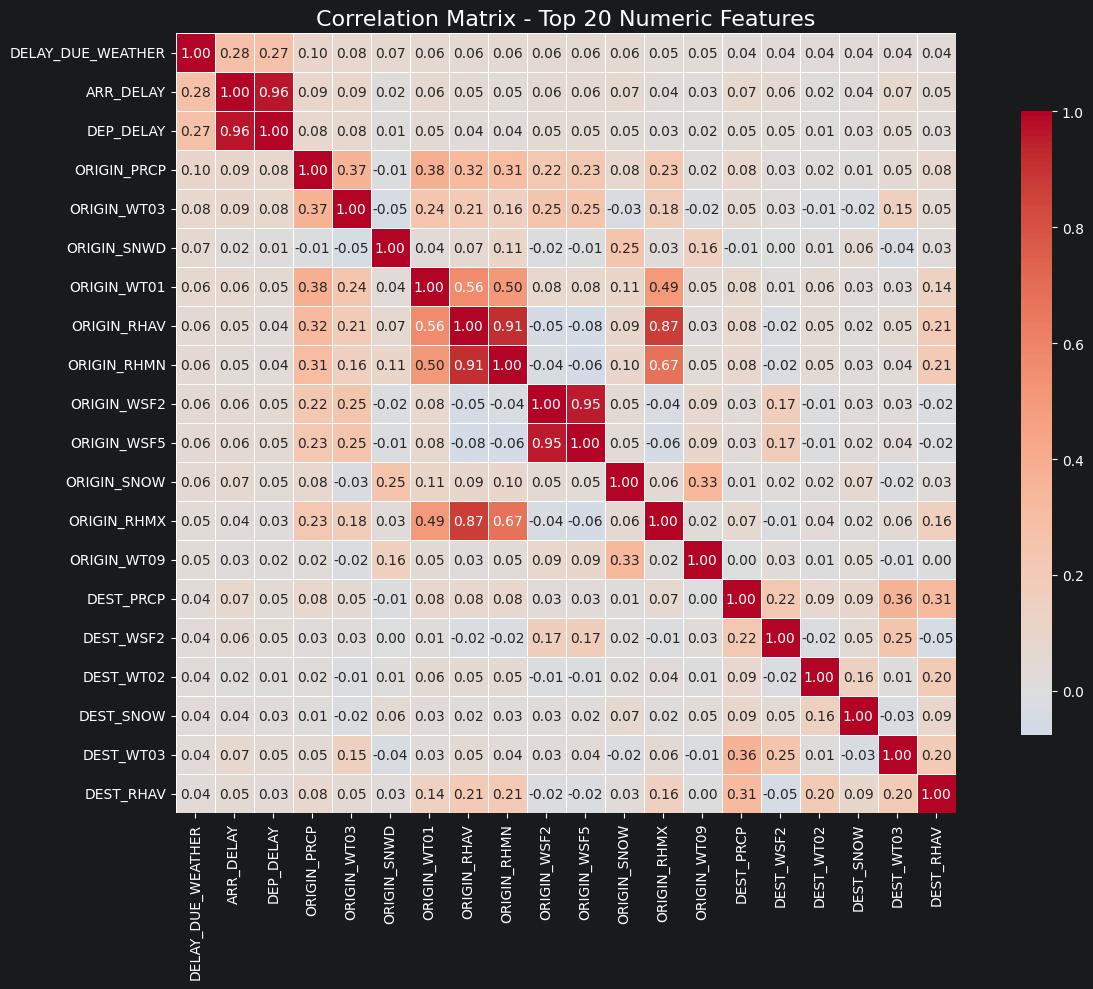

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation of all numeric columns with DEP_DELAY
numeric_df = df.select_dtypes(include=['number', 'boolean'])
cols = ["DEP_DELAY", "ARR_DELAY", "DELAY_DUE_WEATHER"] + [c for c in numeric_df.columns if c.startswith("ORIGIN") or c.startswith("DEST")]

if 'DEP_DELAY' in numeric_df.columns:
    dep_delay_corr = numeric_df[cols].corr()['DELAY_DUE_WEATHER'].sort_values(ascending=False)
else:
    print("DEP_DELAY column not found")
dep_delay_corr

# Select top numeric columns for readability (top 20 by variance)
top_cols = dep_delay_corr.sort_values(ascending=False).head(20).index.tolist()
# Compute correlation matrix
corr_matrix = numeric_df[top_cols].corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix - Top 20 Numeric Features', fontsize=16)
plt.tight_layout()
plt.show()

In [123]:
DATASET = df[df["CANCELLED"] != 1][cols].drop(columns=["ARR_DELAY"]).reset_index(drop=True)
DATASET

,DEP_DELAY,DELAY_DUE_WEATHER,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,ORIGIN_ELEVATION,ORIGIN_PRCP,ORIGIN_SNOW,ORIGIN_SNWD,ORIGIN_TMAX,ORIGIN_TMIN,...,DEST_ADPT,DEST_RHAV,DEST_RHMN,DEST_RHMX,DEST_WT04,DEST_WT05,DEST_WT06,DEST_WT07,DEST_WT09,DEST_WT18
0,-10.0,NaN,26.91847,-81.99391,6.1,0.0,0.0,0.0,283.0,156.0,...,-50.0,70.0,43.0,85.0,False,False,False,False,False,False
1,-7.0,NaN,35.06836,-77.04783,3.2,0.0,0.0,0.0,294.0,161.0,...,94.0,53.0,36.0,72.0,False,False,False,False,False,False
2,25.0,0.0,35.04189,-106.61545,1618.4,0.0,0.0,0.0,172.0,11.0,...,-28.0,57.0,25.0,96.0,False,False,False,False,False,False
3,0.0,NaN,40.48459,-80.21448,341.0,0.0,0.0,0.0,256.0,122.0,...,128.0,47.0,30.0,71.0,False,False,False,False,False,False
4,-2.0,NaN,33.93816,-118.38660,29.7,0.0,0.0,0.0,272.0,156.0,...,67.0,71.0,47.0,97.0,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97488,-3.0,NaN,32.89945,-80.04070,11.8,0.0,0.0,0.0,206.0,44.0,...,28.0,48.0,34.0,67.0,False,False,False,False,False,False
97489,129.0,0.0,41.78412,-87.75514,185.8,0.0,0.0,0.0,44.0,-32.0,...,-6.0,35.0,12.0,72.0,False,False,False,False,False,False
97490,3.0,NaN,36.90371,-76.19266,3.3,0.0,0.0,0.0,317.0,239.0,...,194.0,74.0,46.0,100.0,False,False,False,False,False,False
97491,3.0,NaN,39.04443,-84.67241,262.4,0.0,0.0,0.0,217.0,167.0,...,133.0,74.0,60.0,84.0,False,False,False,False,False,False


In [124]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
DATASET = DATASET.select_dtypes(include=['number', 'boolean'])
DATASET[DATASET.select_dtypes(include='boolean').columns] = DATASET.select_dtypes(include='boolean').astype(int)
x = sm.add_constant(x)
xs = "ORIGIN_PRCP"
REMOVED = ["ORIGIN_LATITUDE", "ORIGIN_ELEVATION", "ORIGIN_LONGITUDE", "DEST_LATITUDE", "DEST_ELEVATION", "DEST_LONGITUDE", "ORGIN_PRCP", "DELAY_DUE_WEATHER", "DEP_DELAY"]
for col in DATASET.columns[1:]:
    if col not in REMOVED:
        xs += f" + {col}"

results = smf.ols(formula=f"DEP_DELAY ~ {xs}", missing="drop", data=DATASET).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              DEP_DELAY   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     29.80
Date:                Tue, 05 May 2026   Prob (F-statistic):          8.71e-271
Time:                        17:59:38   Log-Likelihood:            -4.0140e+05
No. Observations:               75575   AIC:                         8.029e+05
Df Residuals:                   75525   BIC:                         8.034e+05
Df Model:                          49                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     -15.1498      5.421     -2.795      